# Análisis exploratorio sensores y selección para el caso de estudio
 Para la selección de sensores dentro de Chamberí, se amplía el análisis a los tres años del periodo de estudio (2023, 2024 y 2025), sumando 36 meses en total. Esta ampliación es necesaria porque un sensor con buena cobertura en 2025 pero con huecos prolongados en 2023 o 2024 introduciría series incompletas justo en el periodo de aprendizaje, comprometiendo la calidad del modelo predictivo.

## Configuración

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from pathlib import Path
import calendar
import re
import unicodedata
from matplotlib.lines import Line2D

In [62]:
BASE_DIR = Path(r'C:\Users\ElsaBlacoArmengod\OneDrive - Educa Bidco\Escritorio\personal\TFM\dataset')

SEPARADOR    = ";"
DISTRITO_OBJ = 7
TIPO_ELEM_OBJ = "URB"
TAM_BLOQUE = 2_000_000
SEPARADOR = ';'
FORMATO_FECHA = '%Y-%m-%d %H:%M:%S'

CARPETA_SALIDA = Path(r'C:\Users\ElsaBlacoArmengod\OneDrive - Educa Bidco\Escritorio\personal\TFM\resultados\sensores')
CARPETA_SALIDA.mkdir(parents=True,exist_ok=True)

## Dataset puntos de medida

### Lectura de los puntos de medida del distrito de Chamberí

In [63]:
FICHEROS_PTOS_MEDIDA = {f"{año}{mes:02d}": BASE_DIR / "ptos_medida" / f"{año}{mes:02d}.csv" for año in range(2023, 2026) for mes in range(1, 13)}

N_MESES_TOTAL = len(FICHEROS_PTOS_MEDIDA)

# Se lee cada fichero y se almacenan los sensores URB del distrito 7
registros = {} 
for mes, ruta in FICHEROS_PTOS_MEDIDA.items():
    df = pd.read_csv(ruta, sep=SEPARADOR, encoding="latin-1")
    df["id"]       = df["id"].astype(str).str.strip()
    df["distrito"] = pd.to_numeric(df["distrito"], errors="coerce")
    df = df.dropna(subset=["distrito"])
    df["distrito"] = df["distrito"].astype(int)
    df = df[(df["tipo_elem"].astype(str).str.strip().str.upper() == TIPO_ELEM_OBJ) &(df["distrito"] == DISTRITO_OBJ)]
    registros[mes] = df

### Estabilidad de los puntos de medidas

 En primer lugar, vamos a ver si para el periodo de 3 años que se va a estudiar se tienen todos los meses los mismos sensores para el distrito seleccionado.

In [64]:
print("\nClasificación de sensores por estabilidad")

todos_ids = sorted(set().union(*[set(df["id"]) for df in registros.values()]))

presencia = pd.DataFrame(index=todos_ids, columns=list(FICHEROS_PTOS_MEDIDA.keys()), dtype=int)
for mes, df in registros.items():
    presencia[mes] = presencia.index.isin(df["id"]).astype(int)

presencia["n_meses"] = presencia.sum(axis=1)

estable = presencia[presencia["n_meses"] == N_MESES_TOTAL].index.tolist()
inestable = presencia[presencia["n_meses"] < N_MESES_TOTAL].index.tolist()

print(f"Número de sensores presentes en los {N_MESES_TOTAL} meses: {len(estable)}")
print(f"Número de sensores con ausencias en algún mes: {len(inestable)}")

# En qué meses faltaron
if inestable:
    print("\nDetalle de sensores ausentes en algún mes (meses ausentes):")
    for i in inestable:
        meses_ausentes = [m for m in FICHEROS_PTOS_MEDIDA if presencia.loc[i, m] == 0]
        print(f"{i} ID  ausente en: {', '.join(meses_ausentes)}")

resumen = (presencia.reset_index().rename(columns={"index": "id"}).groupby("n_meses")["id"].agg(n_sensores="count", ids=lambda x: ", ".join(map(str, x))).sort_index(ascending=False).reset_index())
print("\n Resumen estabilidad sensores:")
print(resumen.to_string(index=False))
ruta_csv = CARPETA_SALIDA / "resumen_estabilidad_sensores.csv"
resumen.to_csv(ruta_csv, sep=SEPARADOR, index=False, encoding="latin-1")

sensor_inestable = inestable
sensores_estables = estable


Clasificación de sensores por estabilidad
Número de sensores presentes en los 36 meses: 141
Número de sensores con ausencias en algún mes: 1

Detalle de sensores ausentes en algún mes (meses ausentes):
7081 ID  ausente en: 202311, 202401, 202402, 202403, 202404, 202405, 202406, 202407, 202408, 202409, 202410, 202411, 202412, 202501, 202502, 202503, 202504, 202505, 202506, 202507, 202508, 202509, 202510, 202511, 202512

 Resumen estabilidad sensores:
 n_meses  n_sensores                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

Por lo tanto, el único sensor que no aparece en todos los meses estudiados es el 7081 por lo que no será candidato a ser seleccionado, ya que solo aparece en los primeros 11 meses y tendremos 141 sensores por mes.

Se va a usar como dataset de puntos de medida el correspondiente a diciembre de 2025 ya que se ha visto anteriormente, que los 141 sensores estables forman parte de dicho conjunto.

In [65]:
df_id = pd.read_csv(BASE_DIR / 'ptos_medida' / '202512.csv', sep=';', encoding='latin-1')
df_id = df_id[(df_id["tipo_elem"]== 'URB') & (df_id["distrito"]== 7)]
df_id = df_id[['id','nombre']]

print(f'Hay {len(df_id["id"].unique())} sensores en Chamberí.')

Hay 141 sensores en Chamberí.


## Dataset histórico

### Carga del histórico y sensores en el histórico

Se van a cargar ahora los datos históricos correspondientes a los 141 sensores a lo largo de tres años de estudio, asociados a la categoría urbana  y al distrito de Chamberí.

In [66]:
FICHEROS_HISTORICO = {f"{mes:02d}{año}": BASE_DIR / "historico" / f"{mes:02d}{año}.zip" for año in range(2023, 2026) for mes in range(1, 13)}

COLUMNAS   = ["id", "fecha", "carga"]
acumulado  = []
meses_leidos = 0

for nombre, ruta in FICHEROS_HISTORICO.items():
    print(f"  {nombre} ", end=" ")
    filas_mes = 0

    for bloque in pd.read_csv(ruta, sep=SEPARADOR, usecols=COLUMNAS,chunksize=TAM_BLOQUE, encoding="latin-1",compression="zip"):
        bloque["id"] = bloque["id"].astype(str).str.strip()
        bloque = bloque[bloque["id"].isin(sensores_estables)].copy()
        if bloque.empty:
            continue
        bloque["carga"] = pd.to_numeric(bloque["carga"], errors="coerce")
        bloque = bloque[bloque["carga"] >= 0]
        bloque["fecha"] = pd.to_datetime(bloque["fecha"], format=FORMATO_FECHA, errors="coerce")
        bloque = bloque.dropna(subset=["fecha"])
        bloque["hora"] = bloque["fecha"].dt.hour
        bloque["dia_semana"]  = bloque["fecha"].dt.dayofweek
        bloque["es_laborable"]= bloque["dia_semana"] < 5

        agregado = (bloque.groupby(["id", "es_laborable", "hora"])["carga"].agg(carga="sum", mediciones="count").reset_index())
        acumulado.append(agregado)
        filas_mes += len(bloque)

    print(f"{filas_mes:,} registros")
    meses_leidos += 1

df = pd.concat(acumulado, ignore_index=True)
df = df.groupby(["id", "es_laborable", "hora"], as_index=False)[["carga", "mediciones"]].sum()
df["carga_media"] = df["carga"] / df["mediciones"]

  012023  393,277 registros
  022023  352,718 registros
  032023  389,562 registros
  042023  379,290 registros
  052023  393,743 registros
  062023  381,994 registros
  072023  393,674 registros
  082023  389,814 registros
  092023  379,782 registros
  102023  392,328 registros
  112023  381,419 registros
  122023  391,451 registros
  012024  392,401 registros
  022024  367,470 registros
  032024  393,636 registros
  042024  380,848 registros
  052024  390,173 registros
  062024  380,067 registros
  072024  385,300 registros
  082024  371,789 registros
  092024  374,689 registros
  102024  390,726 registros
  112024  372,517 registros
  122024  391,470 registros
  012025  387,994 registros
  022025  346,891 registros
  032025  389,717 registros
  042025  352,554 registros
  052025  389,025 registros
  062025  376,583 registros
  072025  391,147 registros
  082025  384,535 registros
  092025  379,270 registros
  102025  394,437 registros
  112025  373,351 registros
  122025  378,498 re

Posteriormente, se van a comprobar los sensores que se encuentran en el periodo de estudio en el histórico.

In [67]:
def dias_reales(años):
    return sum(366 if calendar.isleap(a) else 365 for a in años) # diferencia de días en los años bisiestos

DIAS_TOTALES_REALES = dias_reales([2023, 2024, 2025]) 
FREQ_REG_HORA       = 4
MEDICIONES_ESPERADAS = DIAS_TOTALES_REALES * 24 * FREQ_REG_HORA 

print(f"Meses leídos: {meses_leidos}")
print(f"Meses totales conjunto datos: {len(FICHEROS_HISTORICO)}")
print(f"Sensores con datos: {df['id'].nunique()}")

Meses leídos: 36
Meses totales conjunto datos: 36
Sensores con datos: 134


De los 141 sensores del distrito tienen datos 134, vamos a ver que ocurre con los restantes. 

In [68]:
sensores_con_datos = set(df["id"].unique())
sensores_sin_datos = set(sensores_estables) - sensores_con_datos

print(f"Número de sensores esperados: {len(sensores_estables)}")
print(f"Número de sensores con datos: {len(sensores_con_datos)}")
print(f"Número de sensores sin ningún dato en el histórico: {len(sensores_sin_datos)}")
print(f"Sensores sin dato en el histórico {sensores_sin_datos}")

Número de sensores esperados: 141
Número de sensores con datos: 134
Número de sensores sin ningún dato en el histórico: 7
Sensores sin dato en el histórico {'4469', '4397', '4467', '10560', '4466', '4468', '4465'}


De los 141 sensores candidatos identificados en el distrito 7 (Chamberí), hay 7 sensores (sensores_sin datos) (4465, 4466, 4467, 4468, 4469, 4397, 10560) que  no presentan ningún registro en el periodo de estudio, por lo que se van a excluir. Esto reduce el conjunto final de 141 sensores estables que hay en el conjunto de puntos de medida, a 134 sensores estables que tienen datos históricos. 

Posteriormente, se va a desarrollar un clasificador de las distintas tipologías viarias. 

## Tipologías viarias

A continuación, en los sensores con datos se aplica una clasificación en cuatro tipologías viarias a partir de palabras clave en el nombre de la vía asociada a cada punto de medida. Esta clasificación se debe a las distintas funcionalidades que cada tipo de calle cuenta en la movilidad del distrito y sus posibles diferencias en la simulación de la implementación de medidas de gestión de movilidad laboral.

In [69]:
def quita_tildes(s: str) -> str:
    return ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')
 
def via_principal(nombre: str) -> str: # normaliza formato y abreviaturas
    n = str(nombre).lower()
    n = re.sub(r'\(aforos?\)|\(micro\)|\(tactico\)', '', n)
    n = n.split('(')[0].split(',')[0]
    n = re.sub(r'\b[oens]-[oens]\b', '', n)     
    n = n.split(' - ')[0]                       
    n = quita_tildes(n)
    n = re.sub(r'\bsta\.?', 'santa ', n)
    n = n.replace('pº', 'paseo ')
    n = re.sub(r'\bav\.?\b', 'avenida', n)
    n = re.sub(r'\bgral\.?', 'general ', n)
    n = re.sub(r'\bfdez\.?', 'fernandez ', n)
    n = re.sub(r'[.\d]', '', n)
    n = re.sub(r'\s+', ' ', n).strip(' -')
    return n
 
# Diccionario
CLASIF = {
    "Arterial": [
        "paseo castellana", "castellana", "bravo murillo", "reina victoria",
        "moncloa", "fernandez de los rios", "juan xxiii",
    ],
    "Principal": [
        "santa engracia", "jose abascal", "raimundo fernandez villaverde",
        "alberto aguilera", "genova", "sagasta", "eduardo dato", "rios rosas",
        "cea bermudez", "carranza", "fuencarral", "princesa",
    ],
    "Secundaria": [
        "almagro", "zurbano", "modesto lafuente", "fortuny", "miguel angel",
        "isaac peral", "vallehermoso", "guzman el bueno", "donoso cortes",
        "agustin de bethancourt", "alonso cano", "general martinez campos",
        "general ibanez ibero", "garcia paredes",
    ],
    "Residencial": [
        "san francisco de sales", "san francisco sales", "andres mellado",
        "melendez valdes", "blasco de garay", "eloy gonzalo", "fernando el catolico",
        "rodriguez san pedro", "san bernardo", "alburquerque", "luchana",
        "francisco de rojas", "san juan de la cruz", "avenida del valle", "del valle",
    ],
}
TIPOLOGIA_DEFAULT = "Residencial"
 
# Se ordenan las claves de mas larga a mas corta para que gane la coincidencia
# mas especifica (evita que "del valle" capture antes que "avenida del valle").
ORDENADAS = sorted([(c, t) for t, cs in CLASIF.items() for c in cs], key=lambda x: -len(x[0]))
 
def clasificar_tipologia(nombre: str) -> str:
    v = via_principal(nombre)
    for calle, tipo in ORDENADAS:
        if calle in v:
            return tipo
    return TIPOLOGIA_DEFAULT
 
# Clasificación de los sensores
df_id = pd.read_csv(BASE_DIR / 'ptos_medida' / '202512.csv', sep=';', encoding='latin-1')
df_id["id"] = df_id["id"].astype(str).str.strip()
df_id["distrito"] = pd.to_numeric(df_id["distrito"], errors="coerce")
df_id = df_id.dropna(subset=["distrito"])
df_id["distrito"] = df_id["distrito"].astype(int)
 
df_id = df_id[
    (df_id["tipo_elem"].astype(str).str.strip().str.upper() == TIPO_ELEM_OBJ) &
    (df_id["distrito"] == DISTRITO_OBJ) &
    (df_id["id"].isin(sensores_con_datos))].copy()
 
df_id["tipologia"] = df_id["nombre"].apply(clasificar_tipologia)
df_id["via_principal"] = df_id["nombre"].apply(via_principal)
 
# Verificacion para que ninguna esté en dos tipologias
verificacion = df_id.groupby("via_principal")["tipologia"].nunique()
confirmacion = verificacion[verificacion > 1]
print(f"Sensores con datos: {len(sensores_con_datos)}")
print(f"Vias en más de una tipología: {len(confirmacion)}")

 

Sensores con datos: 134
Vias en más de una tipología: 0


### Franja horaria días laborables de mayor demanda

A continuación, visualizamos las cargas a lo largo de las horas para ver cuando existe el pico matutito de carga vial. 

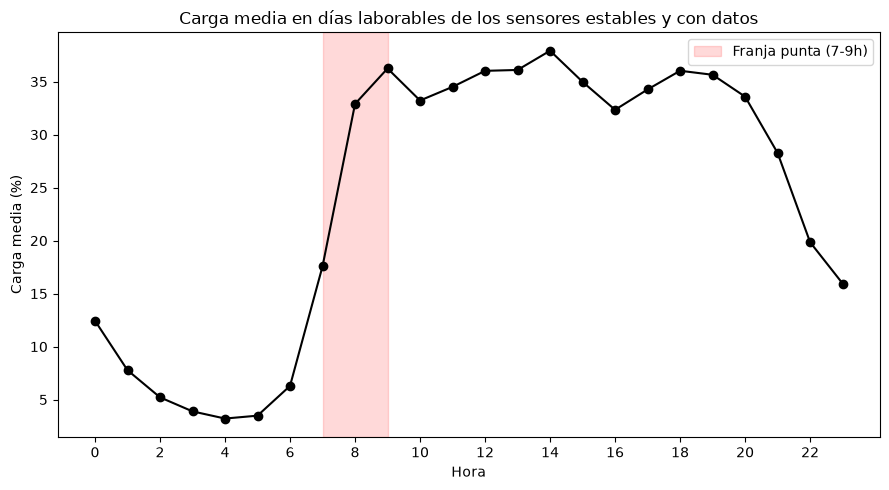

In [70]:
HORA_PUNTA_INICIO = 7
HORA_PUNTA_FIN    = 9
HORAS_PUNTA = set(range(HORA_PUNTA_INICIO, HORA_PUNTA_FIN + 1))

lab = df[df["es_laborable"]].copy()
lab["peso"] = lab["carga_media"] * lab["mediciones"]
perfil_medio_lab = (lab.groupby("hora")["peso"].sum() / lab.groupby("hora")["mediciones"].sum())

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(perfil_medio_lab.index, perfil_medio_lab.values, marker="o",color="black")
ax.axvspan(HORA_PUNTA_INICIO, HORA_PUNTA_FIN, alpha=0.15, color="red", label="Franja punta (7-9h)")
ax.set_xlabel("Hora")
ax.set_ylabel("Carga media (%)")
ax.set_xticks(range(0, 24, 2))
ax.set_title("Carga media en días laborables de los sensores estables y con datos")
ax.legend()
fig.tight_layout()
fig.savefig(CARPETA_SALIDA / "hora_punta_sensores_estables_condatos.png", dpi=150) 
plt.show()


## Selección batería de sensores
Finalmente, se selecciona una batería de sensores ya que el objetivo no es modelar todos los tramos de la red viaria, sino desarrollar un modelo capaz de reproducir y simular el comportamiento del tráfico bajo distintos escenarios urbanos y comparar sus efectos entre tipos de vía. Incluir la totalidad de los sensores aporta información redundante, ya que muchos registran patrones muy similares al ubicarse en vías de características equivalentes. Por ello se seleccionan en base a criterios de representatividad espacial, funcional y de calidad de los datos, garantizando tres sensores por cada una de las cuatro tipologías definidas para que la muestra recoja la diversidad de la movilidad del distrito sin duplicar información.

### Métricas sensibles a políticas laborales

 
Para ello, se calculan tres métricas: 
- La Huella de Movilidad Laboral (HML) que mide la diferencia de carga en hora punta entre días laborables y fines de semana, capturando la sensibilidad al teletrabajo. 
- El Índice de Concentración del Pico Matutino (ICPM) que contabiliza la proporción de carga diaria concentrada en la franja punta en días laborables, reflejando la sensibilidad a la entrada flexible. 
- La completitud que mide la fracción de mediciones registradas frente a las esperadas en el periodo, como criterio de calidad de la serie. Se establece una completitud mínima del 98 % para que como mucho haya menos de un mes sin datos y no nos afecte la calidad de los datos al entrenamiento del modelo.


In [71]:
def perfil_sensor(sid, laborable):
    return df[(df["id"] == sid) & (df["es_laborable"] == laborable)].set_index("hora")["carga_media"]

def hml(sid):
    datos = df[df["id"] == sid]

    def media_punta(laborable):
        s = datos[(datos["es_laborable"] == laborable) & (datos["hora"].isin(HORAS_PUNTA))]
        if s.empty or s["mediciones"].sum() == 0:
            return np.nan
        return np.average(s["carga_media"], weights=s["mediciones"])
    lab, fin = media_punta(True), media_punta(False)
    return round(lab - fin, 2) if pd.notna(lab) and pd.notna(fin) else np.nan

def icpm(sid):
    datos = df[(df["id"] == sid) & (df["es_laborable"] == True)]
    if datos.empty or datos["mediciones"].sum() == 0:
        return np.nan
    total_dia = np.average(datos["carga_media"], weights=datos["mediciones"])
    datos_punta = datos[datos["hora"].isin(HORAS_PUNTA)]
    if datos_punta.empty or total_dia == 0:
        return np.nan
    punta_media = np.average(datos_punta["carga_media"], weights=datos_punta["mediciones"])
    return round(punta_media / total_dia, 4)

def completitud(sid):
    total_med = df[df["id"] == sid]["mediciones"].sum()
    return min(round(total_med / MEDICIONES_ESPERADAS, 3), 1.0)

# Calcula metricas
metricas = []
for sid in df["id"].unique():
    if sid not in sensores_con_datos:
        continue
    metricas.append({
        "id": sid,
        "HML": hml(sid),
        "ICPM": icpm(sid),
        "Completitud": completitud(sid),
        "med_total": int(df[df["id"] == sid]["mediciones"].sum())})

df_metricas = pd.DataFrame(metricas)
df_metricas = df_metricas.merge(df_id[["id", "nombre", "tipologia"]].rename(columns={"nombre": "nombre_via"}),on="id", how="left")
df_metricas["tipologia"] = df_metricas["tipologia"].fillna(TIPOLOGIA_DEFAULT)

El objetivo es trabajar con sensores que tengan un equilibrio favorable entre las medidas presentadas para lo que se realiza una métrica compuesta que utiliza la ponderación mediante AHP. 

La HML recibe la mayor prioridad por medir la sensibilidad a la implementación del efecto más notorio en la carga vial al reducir el número total de desplazamientos los desplazamientos.  El ICPM ocupa el segundo lugar por capturar un efecto de redistribución temporal más sutil en la carga vial. Finalmente, la completitud queda en último lugar por tratarse de un criterio de control de calidad y no de sensibilidad a política alguna. 

In [72]:
# AHP: Cálculo de pesos por comparación pareada (Saaty, 1980)
criterios = ["HML", "ICPM", "Completitud"]

# Matriz de comparación pareada
matriz = np.array([
    [1,   2,   5],   
    [1/2, 1,   4],   
    [1/5, 1/4, 1]])

suma_columnas = matriz.sum(axis=0)
matriz_norm = matriz / suma_columnas
pesos = matriz_norm.mean(axis=1)

print("Pesos obtenidos (AHP):")
for crit, w in zip(criterios, pesos):
    print(f"  {crit}: {w:.4f}")
Peso_HML, Peso_ICPM, Peso_COMPLETITUD = pesos

n = len(criterios)
vector_prioridad = matriz @ pesos  
lambda_max = (vector_prioridad / pesos).mean()

CI = (lambda_max - n) / (n - 1)  # Índice de consistencia

# Índice aleatorio (RI) tabulado por Saaty según tamaño de matriz (n=3, 0.58)
RI_tabla = {1: 0, 2: 0, 3: 0.58, 4: 0.90, 5: 1.12}
RI = RI_tabla[n]

CR = CI / RI if RI != 0 else 0 # Ratio de consistencia

print(f"Índice de consistencia (CI): {CI:.4f}")
print(f"Ratio de consistencia (CR): {CR:.4f}")

if CR < 0.10:
    print("Consistencia aceptable (CR < 0.10)")
else:
    print("Consistencia NO aceptable (CR >= 0.10)")

Pesos obtenidos (AHP):
  HML: 0.5679
  ICPM: 0.3339
  Completitud: 0.0982
Índice de consistencia (CI): 0.0123
Ratio de consistencia (CR): 0.0213
Consistencia aceptable (CR < 0.10)


La matriz de comparación da un ratio de consistencia CR = 0.021, por debajo del umbral de aceptación de 0.10 establecido por Saaty (1980), lo que confirma la coherencia de las decisiones. 

Finalmente, se fija que haya tres sensores por tipología y que la completitud sesa superior a 0.98 y se calcula la métrica compuesta. 

In [79]:
# Cuotas por tipología
CUOTAS = {
    "Arterial":    3,
    "Principal":   3,
    "Secundaria":  3,
    "Residencial": 3}

# Filtro de completitud
COMPLETITUD_MIN   = 0.98
aptos = df_metricas[(df_metricas["Completitud"] >= COMPLETITUD_MIN) &df_metricas["HML"].notna() &df_metricas["ICPM"].notna()].copy()

print(f"Sensores aptos tras filtro de completitud (≥{COMPLETITUD_MIN*100:.0f}%): {len(aptos)} ({100 * len(aptos) / len(sensores_con_datos):.1f}%)")

# Normalización min-max [0, 1] dentro de los aptos
for col in ["HML", "ICPM", "Completitud"]:
    mn, mx = aptos[col].min(), aptos[col].max()
    aptos[f"{col}_norm"] = (aptos[col] - mn) / (mx - mn) if mx > mn else 0.0


aptos["Metrica_compuesta"] = (Peso_HML * aptos["HML_norm"] + Peso_ICPM * aptos["ICPM_norm"] + Peso_COMPLETITUD * aptos["Completitud_norm"]).round(3)

aptos = aptos.sort_values("Metrica_compuesta", ascending=False)
aptos["via_principal"] = aptos["nombre_via"].apply(via_principal)
 
seleccionados          = []
ids_seleccionados      = set()
vias_seleccionadas     = set()   # vias ya ocupadas (global, todas las tipologias)
 
for tipo, cuota in CUOTAS.items():
    candidatos = aptos[(aptos["tipologia"] == tipo) & (~aptos["id"].isin(ids_seleccionados))].sort_values("Metrica_compuesta", ascending=False)
 
    elegidos = []
    for _, r in candidatos.iterrows():
        if len(elegidos) >= cuota:
            break
        if r["via_principal"] in vias_seleccionadas:
            continue                      # ya hay un sensor en esa calle
        elegidos.append(r["id"])
        vias_seleccionadas.add(r["via_principal"])
 
    sub = candidatos[candidatos["id"].isin(elegidos)]
    seleccionados.append(sub)
    ids_seleccionados.update(elegidos)
 
seleccion = pd.concat(seleccionados, ignore_index=True)
seleccion = seleccion.sort_values("Metrica_compuesta", ascending=False).reset_index(drop=True)
seleccion.index += 1
 
# Verificacion: ninguna via repetida en toda la seleccion
_rep = seleccion["via_principal"].duplicated().sum()
print(f"Vias repetidas en la seleccion: {_rep}")
 
cols_out = ["id", "nombre_via", "tipologia", "HML", "ICPM", "Completitud", "Metrica_compuesta"]
print(f"\nSensores seleccionados ({len(seleccion)}):\n")
print(seleccion[cols_out].to_string())
 
# Guardar
aptos.sort_values("Metrica_compuesta", ascending=False).to_csv(
    CARPETA_SALIDA / "ranking_sensores_chamberi.csv", index=False)
seleccion.to_csv(CARPETA_SALIDA / "sensores_seleccionados_chamberi.csv", index=True)

Sensores aptos tras filtro de completitud (≥98%): 94 (70.1%)
Vias repetidas en la seleccion: 0

Sensores seleccionados (12):

       id                                                     nombre_via    tipologia    HML    ICPM  Completitud  Metrica_compuesta
1    4421                Cea Bermúdez, 4 O-E(Boix y Morer-Bravo Murillo)    Principal  39.31  1.5136        0.996              0.915
2    5774                        Av.Moncloa O-E  - La Granja - Del Valle     Arterial  33.51  1.7416        0.990              0.870
3    5777  Av. Reina Victoria O-E  - Gral. Ibáñez Íbero - Pablo Iglesias     Arterial  33.81  1.6040        0.994              0.849
4   10604    Blasco de Garay S-N (Alberto Aguilera -Rodríguez San Pedro)  Residencial  33.75  1.5538        0.996              0.843
5    3469  SAN FRANCISCO DE SALES S-N (ANDRES MELLADO - GUZMAN EL BUENO)  Residencial  33.59  1.6038        0.991              0.826
6    4428         Gral. Martinez Campos, 24 O-E(Fdez. de la Hoz-Zurbano)   S

## Conclusión

Mapa de los 12 sensores seleccionados en Chamberi (Distrito 7).

Distrito(s): [7]  (esperado: [7])
Figura guardada en: C:\Users\ElsaBlacoArmengod\OneDrive - Educa Bidco\Escritorio\personal\TFM\resultados\sensores\mapa_sensores_chamberi.png


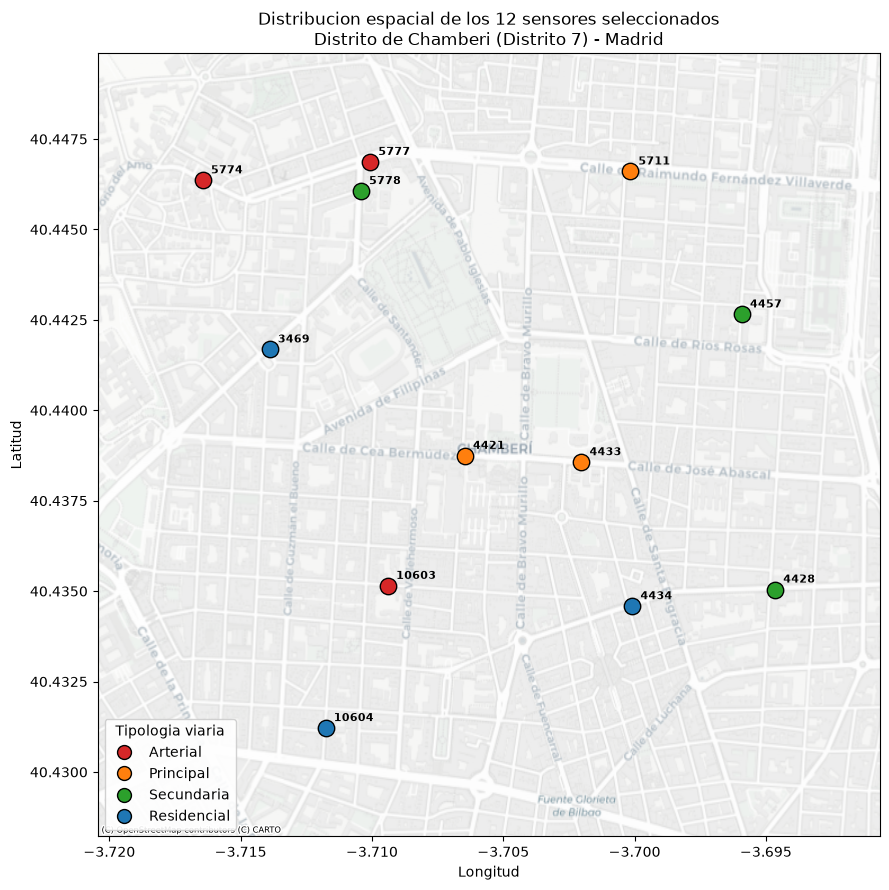

In [80]:
RUTA_PTOS_MEDIDA = BASE_DIR / 'ptos_medida' / '202512.csv'
RUTA_SELECCION   = BASE_MAPA / 'resultados' / 'sensores' / 'sensores_seleccionados_chamberi.csv'
COLORES_TIPOLOGIAS = {
    'Arterial':    '#d62728',
    'Principal':   '#ff7f0e',
    'Secundaria':  '#2ca02c',
    'Residencial': '#1f77b4'}
ORDEN_TIPOS = ['Arterial', 'Principal', 'Secundaria', 'Residencial']
 

sel = pd.read_csv(RUTA_SELECCION)
sel['id'] = sel['id'].astype(str).str.strip()
 
ids = pd.read_csv(RUTA_PTOS_MEDIDA, sep=SEPARADOR, encoding='latin-1')
ids.columns = [c.strip().strip('"') for c in ids.columns]
ids['id'] = ids['id'].astype(str).str.strip()
for col in ['longitud', 'latitud']:
    ids[col] = pd.to_numeric(
        ids[col].astype(str).str.replace(',', '.', regex=False), errors='coerce')
 
df = sel.merge(ids[['id', 'distrito', 'longitud', 'latitud']], on='id', how='left')

print(f'Distrito(s): {df["distrito"].dropna().astype(int).unique()}  (esperado: [7])')
 

fig, ax = plt.subplots(figsize=(9, 9))
 
for tipo in ORDEN_TIPOS:
    sub = df[df['tipologia'] == tipo]
    if sub.empty:
        continue
    ax.scatter(sub['longitud'], sub['latitud'],
               c=COLORES_TIPOLOGIAS[tipo], s=140, edgecolors='black', linewidths=1.0,zorder=5, label=tipo)
    for indice, r in sub.iterrows():
        ax.annotate(r['id'], (r['longitud'], r['latitud']),xytext=(6, 5), textcoords='offset points',fontsize=8, fontweight='bold', zorder=6)
 
try:
    import contextily as cx
    ax.set_xlim(df['longitud'].min() - 0.004, df['longitud'].max() + 0.004)
    ax.set_ylim(df['latitud'].min()  - 0.003, df['latitud'].max()  + 0.003)
    cx.add_basemap(ax, crs='EPSG:4326',
                   source=cx.providers.CartoDB.Positron, attribution_size=6)
except Exception as e:
    print(f'(Sin mapa de fondo: {e})')
    ax.grid(linestyle=':', alpha=0.4)
    ax.set_aspect('equal', adjustable='datalim')
 
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_title('Distribucion espacial de los 12 sensores seleccionados\n'
             'Distrito de Chamberi (Distrito 7) - Madrid', fontsize=12)
 
handles = [Line2D([0], [0], marker='o', linestyle='', markersize=10,
                  markerfacecolor=COLORES_TIPOLOGIAS[t], markeredgecolor='black', label=t)
           for t in ORDEN_TIPOS]
ax.legend(handles=handles, title='Tipologia viaria', loc='lower left',
          framealpha=0.9)
 
fig.tight_layout()
ruta_png = CARPETA_SALIDA / 'mapa_sensores_chamberi.png'
fig.savefig(ruta_png, dpi=300, bbox_inches='tight')
print(f'Figura guardada en: {ruta_png}')
plt.show()